# Repair A Reconstruction

This tutorial shows how to repair cut neurites in an SWC reconstruction. A cut neurite is a branch that stops because the tissue slice ended, not because the neuron really ended there.

You will look at the reconstruction from the side, find likely cut points near the slice surface, mark those points, repair the file, and compare the result.

## Workflow

```text
reconstruction with cut neurites
      |
      v
view dendrites from the side
      |
      v
find tips near the slice surface
      |
      v
mark those node IDs
      |
      v
repair using the same IDs
      |
      v
compare and measure before and after
```

## Reading the repair commands

Repair starts by finding node IDs that may need repair.

```text
swc find data/pass_nmo_2_cut.swc -c 10 -p 3
```

The output is a list of node IDs. Those same IDs are passed to `swc repair`.

```text
swc repair data/pass_nmo_2_cut.swc -c node-ids -o output/repaired.swc
```

| Part | Meaning |
| --- | --- |
| `swc find` | find nodes that match a condition |
| `-c 10` with `find` | look within 10 micrometers of the cut plane |
| `-p 3` | focus on dendrite points |
| `-m node-ids` | mark selected node IDs in a picture |
| `--show-id` | show node ID labels in the picture |
| `swc repair` | create a repaired copy |
| `-c node-ids` with `repair` | tell `repair` which cut points to use |
| `--seed 1` | make the repair repeatable |
| `-o output/repaired.swc` | save the repaired file here |
| `-c shadow` with `view` | compare files by drawing later files as shadows |
| `--shadow-color red` | make the shadow red |
| `--shadow-width 0.5` | make the shadow line thinner |

If the cut surface is at the bottom of the reconstruction instead of the top, add `--bottom-up` to the `find` command.

## What are we looking for?

The sample file has dendrites that end near the top of the slice. These endings are possible cut points.

```text
top slice surface
-----------------
    x   x   x        possible cut points
    |   |   |
    |   |   |        dendrite branches
    |   |   |
```

`swc find` gives us the node IDs for these endings. Then `swc repair` uses those IDs to grow repaired branches from similar intact parts of the reconstruction.

## Command helper

Run this cell once before the tutorial commands. It creates `shell_cmd()`, a small notebook helper that runs terminal commands, shows their output, and displays images when a command creates one.

In [1]:
import subprocess
from pathlib import Path

from IPython.display import Image, display


def shell_cmd(command, image=None):
    print("Executed command:")
    print(command)
    result = subprocess.run(
        command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    output = result.stdout.rstrip()
    print("\nOutput:")
    print(output if output else "(empty)")

    if image is not None and Path(image).exists():
        display(Image(filename=image))


## Copy the damaged reconstruction

Start with a sample file that has cut neurites. The file is copied into `data/` so the commands below can use it.

In [2]:
shell_cmd("cp -v ../tests/data/pass_nmo_2_cut.swc data/")

Executed command:
cp -v ../tests/data/pass_nmo_2_cut.swc data/

Output:
'../tests/data/pass_nmo_2_cut.swc' -> 'data/pass_nmo_2_cut.swc'


## View the damaged reconstruction

First, create a picture of the file before repairing it. We use `-p 3` to focus on dendrites and `-j xz` to view the reconstruction from the side (you can use `-j yz` for another projection).

Executed command:
swc view data/pass_nmo_2_cut.swc -p 3 -j xz -o output/cut_original.png

Output:
(empty)


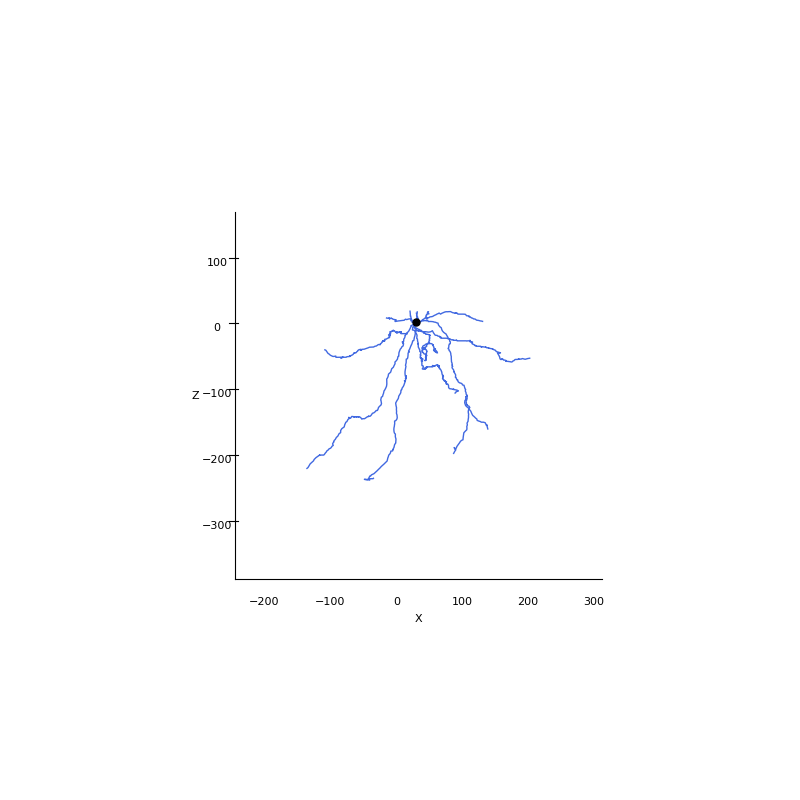

In [3]:
shell_cmd("swc view data/pass_nmo_2_cut.swc -p 3 -j xz -o output/cut_original.png", image="output/cut_original.png")

## Find cut points

Find dendrite tips within 10 μm from the top. The output is a list of node IDs. For this sample file, the IDs are `322 341 547 1167`.

In [4]:
shell_cmd("swc find data/pass_nmo_2_cut.swc -c 10 -p 3")

Executed command:
swc find data/pass_nmo_2_cut.swc -c 10 -p 3

Output:
322 341 547 1167


## Show the cut points

Mark the node IDs found above. This makes the cut points visible before we repair them. Optionally, add parameter `--show-id` to examine the points locations with their IDs and decide whether to keep or remove some of them from the list.

Executed command:
swc view data/pass_nmo_2_cut.swc -p 3 -j xz -m 322 341 547 1167 -o output/cut_points.png

Output:
(empty)


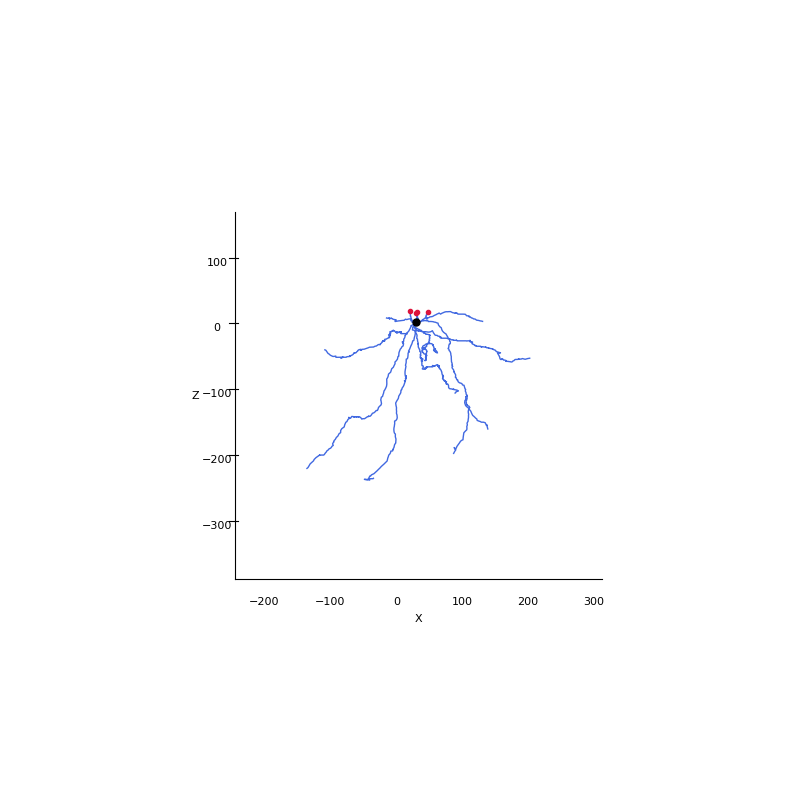

In [5]:
shell_cmd("swc view data/pass_nmo_2_cut.swc -p 3 -j xz -m 322 341 547 1167 -o output/cut_points.png", 
          image="output/cut_points.png")

## Repair the reconstruction

Use the same cut-point IDs to create a repaired copy. The repaired file is saved as `output/repaired.swc`.

In [6]:
shell_cmd("swc repair data/pass_nmo_2_cut.swc -c 322 341 547 1167 --seed 1 -o output/repaired.swc")

Executed command:
swc repair data/pass_nmo_2_cut.swc -c 322 341 547 1167 --seed 1 -o output/repaired.swc

Output:
(empty)


## Compare before and after

View the original and repaired reconstructions together. Shadow mode draws the first file on top and the repaired file as a thin red background comparison.

Executed command:
swc view data/pass_nmo_2_cut.swc output/repaired.swc -p 3 -j xz -c shadow --shadow-color red --shadow-width 0.5 -o output/repaired_compare.png

Output:
(empty)


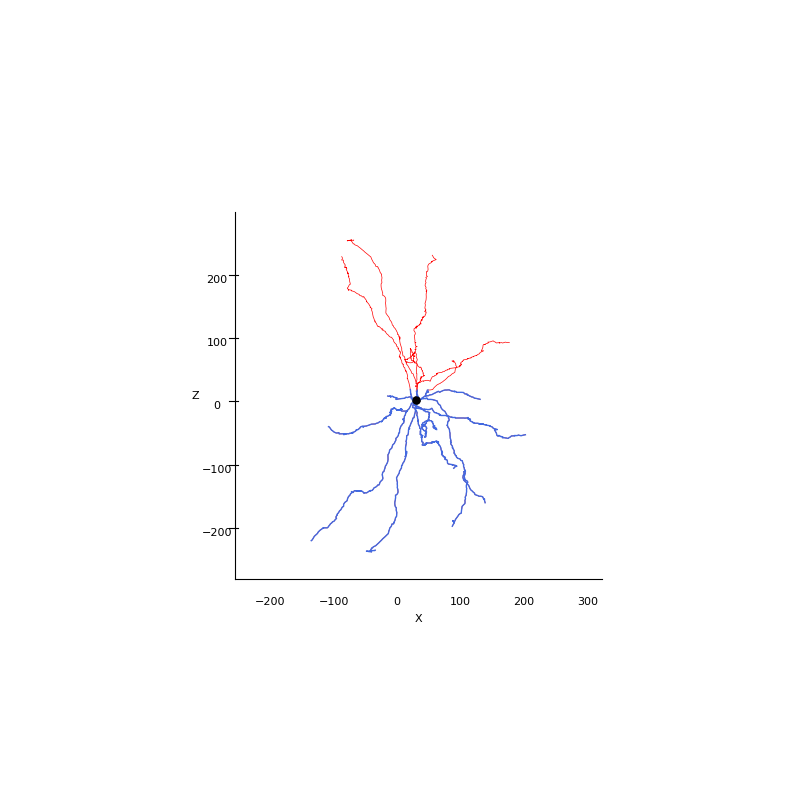

In [7]:
shell_cmd("swc view data/pass_nmo_2_cut.swc output/repaired.swc -p 3 -j xz -c shadow --shadow-color red --shadow-width 0.5 -o output/repaired_compare.png", 
          image="output/repaired_compare.png")


## Measure Before And After

Compare the measurements of the original and repaired files. This helps check how the repair changed the reconstruction.

In [8]:
shell_cmd("swc measure data/pass_nmo_2_cut.swc output/repaired.swc")

Executed command:
swc measure data/pass_nmo_2_cut.swc output/repaired.swc

Output:
pass_nmo_2_cut
axon area          30866
axon breadth          90
axon contrac    0.879087
axon degree            2
axon diam       0.739368
axon dist        599.374
axon length      14308.4
axon nbranch          89
axon nstem             1
axon nterm            90
axon order            16
axon seclen      79.9352
axon volume       6413.1
axon xdim            639
axon ydim         769.28
axon zdim         302.85
dend area        11141.3
dend breadth           4
dend contrac    0.830311
dend degree            2
dend diam        1.33095
dend dist        304.097
dend length      2983.27
dend nbranch           7
dend nstem             7
dend nterm            14
dend order             3
dend seclen       142.06
dend volume      3478.37
dend xdim         337.95
dend ydim          555.8
dend zdim         256.31
soma area        1937.52
soma diam         14.338
soma volume      4630.01
soma xroot         29.51
so